## hls4ml Conversion

Convert the quantized model to HLS (High-Level Synthesis) code for FPGA deployment. Precision is automatically inferred from the HGQ2 model.

In [1]:
import os, subprocess
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# Package imports
from neuroposasic.data import load_dataset

import hls4ml

from sklearn.metrics import log_loss, accuracy_score # sklearn has an easy interface for testing
from scipy.special import softmax # log_loss requires probabilities not found in HLS because 'from_logits=True'

from copy import deepcopy

BUILD = False

I0000 00:00:1777568429.158805    9803 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Loading

In [2]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


## Model Loading

In [3]:
model_path = "output/posture_classifier_qat.keras"
model_qat = keras.models.load_model(model_path)

I0000 00:00:1777568432.665211    9803 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5136 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


## hls4ml

In [4]:
# Make Vitis available in path
script = "/home/jeison/AMD/2025.2/Vitis/settings64.sh"

for line in subprocess.check_output(f'source "{script}" >/dev/null && env', shell=True, executable='/bin/bash', text=True).splitlines():
    if '=' in line:
        k, v = line.split('=', 1)
        os.environ[k] = v

In [5]:
base_config = hls4ml.utils.config_from_keras_model(model_qat, granularity='name')

overrides = {
    'Model': {
        'Strategy': 'Resource',
        'ReuseFactor': 108,
        'IOType': 'io_stream',
        'Precision': 'fixed<16,6>'
    },
    'LayerName': {
        'output': {'ReuseFactor': 60},
    }
}
# Deep merge helper
def deep_merge(base, override):
    result = deepcopy(base)
    for key, value in override.items():
        if key in result and isinstance(result[key], dict) and isinstance(value, dict):
            result[key] = deep_merge(result[key], value)
        else:
            result[key] = value
    return result

config = deep_merge(base_config, overrides)

# Convert model
hls_model = hls4ml.converters.convert_from_keras_model(
    model_qat,
    hls_config=config,
    output_dir='../vitis',
    backend='Vitis',
    part='xc7z020clg400-1', # Pynq-Z2
    clock_period=5,
    clock_uncertainty='12.5%',
)

# Compile and synthesize the model
hls_model.compile()

# Build with various options
if BUILD:
    report = hls_model.build(
        # reset=False,      # Reset project before build
        csim=True,        # Run C simulation
        synth=True,       # Run HLS synthesis
        # cosim=False,      # Run co-simulation
        # validation=False, # Run validation
        export=True,     # Export IP
        vsynth=True      # Run Vivado synthesis
    )

### Model

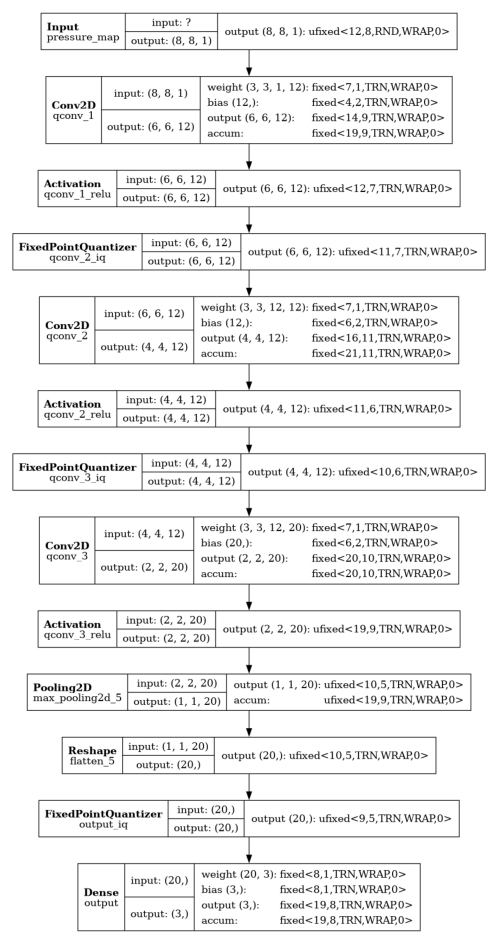

In [6]:
hls4ml.utils.plot_model(hls_model, to_file="output/hls_model.png", show_shapes=True, show_precision=True)

plt.figure(figsize=(12, 12))
plt.imshow(plt.imread("output/hls_model.png"))
plt.axis("off")
plt.show()

### Report

In [7]:
if BUILD:
    # Latency (cycles)
    best_latency = int(report['CSynthesisReport']['BestLatency'])
    worst_latency = int(report['CSynthesisReport']['WorstLatency'])
    print(f"Latency: {best_latency} - {worst_latency} cycles")

    # Clock (ns)
    target_clock = float(report['CSynthesisReport']['TargetClockPeriod'])
    estimated_clock = float(report['CSynthesisReport']['EstimatedClockPeriod'])
    print(f"Target Clock = {target_clock} ns | Estimated Clock = {estimated_clock} ns")

    # Available resources
    avail_LUT = int(report['CSynthesisReport']['AvailableLUT'])
    avail_FF = int(report['CSynthesisReport']['AvailableFF'])
    avail_DSP = int(report['CSynthesisReport']['AvailableDSP'])
    avail_BRAM = int(report['CSynthesisReport']['AvailableBRAM_18K'])

    # Used resources (Vitis HLS)
    used_LUT = int(report['CSynthesisReport']['LUT'])
    used_FF = int(report['CSynthesisReport']['FF'])
    used_DSP = int(report['CSynthesisReport']['DSP'])
    used_BRAM = int(report['CSynthesisReport']['BRAM_18K'])

    # Calculate percentages
    used_LUT_pct = (used_LUT / avail_LUT) * 100
    used_FF_pct = (used_FF / avail_FF) * 100
    used_DSP_pct = (used_DSP / avail_DSP) * 100
    used_BRAM_pct = (used_BRAM / avail_BRAM) * 100

    # Vitis HLS Resources
    print(f"\n--- Vitis HLS Resource Utilization ---")
    print(f"LUT:  {used_LUT:>6} / {avail_LUT:>6} ({used_LUT_pct:>5.2f}%)")
    print(f"FF:   {used_FF:>6} / {avail_FF:>6} ({used_FF_pct:>5.2f}%)")
    print(f"DSP:  {used_DSP:>6} / {avail_DSP:>6} ({used_DSP_pct:>5.2f}%)")
    print(f"BRAM: {used_BRAM:>6} / {avail_BRAM:>6} ({used_BRAM_pct:>5.2f}%)")

    # Used resources (Vivado)
    used_LUT_v = int(report['VivadoSynthReport']['LUT'])
    used_FF_v = int(report['VivadoSynthReport']['FF'])
    used_DSP_v = int(report['VivadoSynthReport']['DSP48E'])
    used_BRAM_v = int(report['VivadoSynthReport']['BRAM_18K'])

    # Calculate percentages
    used_LUT_v_pct = (used_LUT_v / avail_LUT) * 100
    used_FF_v_pct = (used_FF_v / avail_FF) * 100
    used_DSP_v_pct = (used_DSP_v / avail_DSP) * 100
    used_BRAM_v_pct = (used_BRAM_v / avail_BRAM) * 100

    # Vivado Synthesis Resources
    print(f"\n--- Vivado Synthesis Resource Utilization ---")
    print(f"LUT:  {used_LUT_v:>6} / {avail_LUT:>6} ({used_LUT_v_pct:>5.2f}%)")
    print(f"FF:   {used_FF_v:>6} / {avail_FF:>6} ({used_FF_v_pct:>5.2f}%)")
    print(f"DSP:  {used_DSP_v:>6} / {avail_DSP:>6} ({used_DSP_v_pct:>5.2f}%)")
    print(f"BRAM: {used_BRAM_v:>6} / {avail_BRAM:>6} ({used_BRAM_v_pct:>5.2f}%)")

### Evaluation

In [ ]:
# From Scr_2_HLS4ML_Vivado_generator

y_hls = hls_model.predict(X_test) # Executes the FPGA firmware with bit-accurate emulation on the CPU.
y_hls_prob = softmax(y_hls, axis=1) # Convert logits to probabilities for log_loss

# Calculating accuracy and crossentropy loss of HLS_model
hls_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))
hls_crossentropyloss = log_loss(y_true=y_test, y_pred=y_hls_prob)
metrics_tuple = (hls_crossentropyloss, hls_accuracy)

print("_"*40)
print("HLS4ML model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(metrics_tuple[0], metrics_tuple[1]*100))    
## Determine accuracy of Keras model, for comparison
keras_score = model_qat.evaluate(X_test, y_test, verbose=0)
print("Keras  model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(keras_score[0], keras_score[1]*100))
print("_"*40)

2


KeyboardInterrupt: 